<a href="https://colab.research.google.com/github/Bharath-7-7/my-ML-project/blob/main/electricity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Electricity Bill Prediction using Machine Learning:**

1.**Introduction:**
Electricity consumption is increasing rapidly, making it important to estimate future bills.
This project uses machine learning algorithms to predict electricity bills based on usage and other factors.

2.**Objective:**
To predict electricity bills accurately
To analyze factors affecting electricity consumption
To compare different machine learning models

3.**Problem Statement:**
Manual calculation of electricity bills is time-consuming and not predictive.

**Import libraries**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Import DataSets**

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/electricity_bill_full_dataset_14000.xlsx')

In [ ]:
df

,Customer_ID,Month,Year,Region,Consumer_Type,Connected_Load_kW,Units_Consumed_kWh,Peak_Units_kWh,OffPeak_Units_kWh,Tariff_Rate_per_kWh,...,Fixed_Charge,Fuel_Adjustment_Charge,Electricity_Duty,Subsidy_Amount,Temperature_Avg_C,Humidity_%,Power_Cut_Hours,Holiday_Count,Working_Days,Electricity_Bill
0,1,7,2025,East,Residential,34.68,446.73,407.40,38.25,5.66,...,60.05,38.33,65.14,375.07,10.2,64.1,6.3,6,24,7315.74
1,2,4,2024,North,Commercial,12.00,995.78,376.88,572.19,8.22,...,288.09,169.09,28.78,290.38,37.6,62.5,10.7,2,22,13114.50
2,3,11,2025,South,Commercial,33.28,308.11,406.53,899.05,8.69,...,264.57,11.41,40.69,29.40,22.5,40.6,0.6,6,19,5940.55
3,4,8,2024,North,Commercial,39.15,1233.73,372.46,543.47,7.84,...,172.03,10.70,57.94,226.99,43.3,35.8,16.5,2,23,14833.52
4,5,5,2023,South,Residential,34.15,1138.12,228.33,73.17,10.73,...,270.55,27.98,30.05,66.26,14.4,53.6,13.5,3,26,14024.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13995,13996,4,2022,West,Residential,8.73,774.63,108.66,667.13,4.40,...,165.83,149.34,44.81,398.44,20.0,31.4,15.0,3,19,4028.39
13996,13997,1,2025,West,Residential,28.33,83.50,91.13,537.94,10.91,...,121.40,122.49,63.43,470.42,35.6,46.8,5.9,1,23,1762.16
13997,13998,9,2025,North,Commercial,43.75,1419.78,81.00,806.18,3.01,...,195.93,103.82,19.29,184.86,45.0,86.6,2.6,5,24,5559.54
13998,13999,5,2022,North,Residential,4.41,177.50,166.82,328.35,7.59,...,177.81,126.87,91.70,214.91,10.4,NaN,1.2,1,19,3106.81


**Data Preview**

In [ ]:
df.head(2)

,Month,Year,Connected_Load_kW,Units_Consumed_kWh,Peak_Units_kWh,OffPeak_Units_kWh,Tariff_Rate_per_kWh,Peak_Tariff_Rate,Fixed_Charge,Fuel_Adjustment_Charge,Electricity_Duty,Subsidy_Amount,Temperature_Avg_C,Humidity_%,Power_Cut_Hours,Holiday_Count,Working_Days,Electricity_Bill
0,7,2025,34.68,446.73,407.40,38.25,5.66,12.27,60.05,38.33,65.14,375.07,10.2,64.1,6.3,6,24,7315.74
1,4,2024,12.00,995.78,376.88,572.19,8.22,12.56,288.09,169.09,28.78,290.38,37.6,62.5,10.7,2,22,13114.50


In [ ]:
df.tail(3)

,Month,Year,Connected_Load_kW,Units_Consumed_kWh,Peak_Units_kWh,OffPeak_Units_kWh,Tariff_Rate_per_kWh,Peak_Tariff_Rate,Fixed_Charge,Fuel_Adjustment_Charge,Electricity_Duty,Subsidy_Amount,Temperature_Avg_C,Humidity_%,Power_Cut_Hours,Holiday_Count,Working_Days,Electricity_Bill
13995,4,2022,8.73,774.63,108.66,667.13,4.40,6.06,165.83,149.34,44.81,398.44,20.0,31.4,15.0,3,19,4028.39
13996,1,2025,28.33,83.50,91.13,537.94,10.91,11.13,121.40,122.49,63.43,470.42,35.6,46.8,5.9,1,23,1762.16
13997,9,2025,43.75,1419.78,81.00,806.18,3.01,14.22,195.93,103.82,19.29,184.86,45.0,86.6,2.6,5,24,5559.54


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14000 entries, 0 to 13999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             14000 non-null  int64  
 1   Month                   14000 non-null  int64  
 2   Year                    14000 non-null  int64  
 3   Region                  14000 non-null  object 
 4   Consumer_Type           14000 non-null  object 
 5   Connected_Load_kW       14000 non-null  float64
 6   Units_Consumed_kWh      14000 non-null  float64
 7   Peak_Units_kWh          14000 non-null  float64
 8   OffPeak_Units_kWh       14000 non-null  float64
 9   Tariff_Rate_per_kWh     14000 non-null  float64
 10  Peak_Tariff_Rate        14000 non-null  float64
 11  Fixed_Charge            14000 non-null  float64
 12  Fuel_Adjustment_Charge  14000 non-null  float64
 13  Electricity_Duty        14000 non-null  float64
 14  Subsidy_Amount          13300 non-null

In [ ]:
df.describe()

,Customer_ID,Month,Year,Connected_Load_kW,Units_Consumed_kWh,Peak_Units_kWh,OffPeak_Units_kWh,Tariff_Rate_per_kWh,Peak_Tariff_Rate,Fixed_Charge,Fuel_Adjustment_Charge,Electricity_Duty,Subsidy_Amount,Temperature_Avg_C,Humidity_%,Power_Cut_Hours,Holiday_Count,Working_Days,Electricity_Bill
count,14000.000000,14000.000000,14000.000000,14000.000000,14000.000000,14000.000000,14000.000000,14000.000000,14000.000000,14000.000000,14000.000000,14000.000000,13300.000000,13300.000000,13300.000000,13300.000000,14000.000000,14000.000000,14000.000000
mean,7000.500000,6.506714,2023.500286,25.425813,775.930141,255.084407,507.848926,7.456572,10.004612,173.953985,101.025339,50.458549,250.611080,27.502812,55.218068,9.918211,4.470357,20.495643,8411.778654
std,4041.596219,3.461001,1.115771,14.173585,417.934550,140.624309,286.101787,2.601890,2.893376,72.039251,57.803936,28.931890,143.801433,10.094430,20.288895,5.773016,2.869120,3.454641,4199.628665
min,1.000000,1.000000,2022.000000,1.000000,50.010000,10.020000,10.130000,3.000000,5.000000,50.010000,0.010000,0.000000,0.010000,10.000000,20.000000,0.000000,0.000000,15.000000,396.270000
25%,3500.750000,3.000000,2023.000000,13.090000,413.037500,134.880000,257.875000,5.170000,7.480000,111.322500,50.880000,25.197500,126.302500,18.900000,37.400000,4.900000,2.000000,17.000000,5209.732500
50%,7000.500000,7.000000,2023.000000,25.410000,779.310000,254.660000,511.565000,7.475000,10.005000,173.510000,101.320000,50.695000,249.875000,27.400000,55.500000,10.000000,4.000000,21.000000,7821.675000
75%,10500.250000,10.000000,2024.250000,37.692500,1138.905000,377.900000,757.510000,9.700000,12.520000,235.770000,151.342500,75.562500,374.120000,36.100000,72.800000,14.900000,7.000000,23.000000,11139.865000
max,14000.000000,12.000000,2025.000000,50.000000,1499.940000,499.940000,999.870000,12.000000,15.000000,299.980000,200.000000,99.990000,499.940000,45.000000,90.000000,20.000000,9.000000,26.000000,23234.000000


In [ ]:
df.shape

(14000, 21)

In [ ]:
df.size

294000

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Month,0
Year,0
Region,0
Consumer_Type,0
Connected_Load_kW,0
Units_Consumed_kWh,0
Peak_Units_kWh,0
OffPeak_Units_kWh,0
Tariff_Rate_per_kWh,0


In [ ]:
df.drop

<bound method DataFrame.drop of        Customer_ID  Month  Year Region Consumer_Type  Connected_Load_kW  \
0                1      7  2025   East   Residential              34.68   
1                2      4  2024  North    Commercial              12.00   
2                3     11  2025  South    Commercial              33.28   
3                4      8  2024  North    Commercial              39.15   
4                5      5  2023  South   Residential              34.15   
...            ...    ...   ...    ...           ...                ...   
13995        13996      4  2022   West   Residential               8.73   
13996        13997      1  2025   West   Residential              28.33   
13997        13998      9  2025  North    Commercial              43.75   
13998        13999      5  2022  North   Residential               4.41   
13999        14000      6  2023  South    Commercial               5.10   

       Units_Consumed_kWh  Peak_Units_kWh  OffPeak_Units_kWh  \
0                  446.73          407.40              38.25   
1                  995.78          376.88             572.19   
2                  308.11          406.53             899.05   
3                 1233.73          372.46             543.47   
4                 1138.12          228.33              73.17   
...                   ...             ...                ...   
13995              774.63          108.66             667.13   
13996               83.50           91.13             537.94   
13997             1419.78           81.00             806.18   
13998              177.50          166.82             328.35   
13999             1005.13          154.15             994.71   

       Tariff_Rate_per_kWh  ...  Fixed_Charge  Fuel_Adjustment_Charge  \
0                     5.66  ...         60.05                   38.33   
1                     8.22  ...        288.09                  169.09   
2                     8.69  ...        264.57                   11.41   
3                     7.84  ...        172.03                   10.70   
4                    10.73  ...        270.55                   27.98   
...                    ...  ...           ...                     ...   
13995                 4.40  ...        165.83                  149.34   
13996                10.91  ...        121.40                  122.49   
13997                 3.01  ...        195.93                  103.82   
13998                 7.59  ...        177.81                  126.87   
13999                 7.70  ...        171.96                    8.45   

       Electricity_Duty  Subsidy_Amount  Temperature_Avg_C  Humidity_%  \
0                 65.14          375.07               10.2        64.1   
1                 28.78          290.38               37.6        62.5   
2                 40.69           29.40               22.5        40.6   
3                 57.94          226.99               43.3        35.8   
4                 30.05           66.26               14.4        53.6   
...                 ...             ...                ...         ...   
13995             44.81          398.44               20.0        31.4   
13996             63.43          470.42               35.6        46.8   
13997             19.29          184.86               45.0        86.6   
13998             91.70          214.91               10.4         NaN   
13999             18.84          157.48               33.7        69.1   

       Power_Cut_Hours  Holiday_Count  Working_Days  Electricity_Bill  
0                  6.3              6            24           7315.74  
1                 10.7              2            22          13114.50  
2                  0.6              6            19           5940.55  
3                 16.5              2            23          14833.52  
4                 13.5              3            26          14024.71  
...                ...            ...           ...               ...  
13995             15.0      

In [ ]:
df.dropna(inplace=True)
df

,Customer_ID,Month,Year,Region,Consumer_Type,Connected_Load_kW,Units_Consumed_kWh,Peak_Units_kWh,OffPeak_Units_kWh,Tariff_Rate_per_kWh,...,Fixed_Charge,Fuel_Adjustment_Charge,Electricity_Duty,Subsidy_Amount,Temperature_Avg_C,Humidity_%,Power_Cut_Hours,Holiday_Count,Working_Days,Electricity_Bill
0,1,7,2025,East,Residential,34.68,446.73,407.40,38.25,5.66,...,60.05,38.33,65.14,375.07,10.2,64.1,6.3,6,24,7315.74
1,2,4,2024,North,Commercial,12.00,995.78,376.88,572.19,8.22,...,288.09,169.09,28.78,290.38,37.6,62.5,10.7,2,22,13114.50
2,3,11,2025,South,Commercial,33.28,308.11,406.53,899.05,8.69,...,264.57,11.41,40.69,29.40,22.5,40.6,0.6,6,19,5940.55
3,4,8,2024,North,Commercial,39.15,1233.73,372.46,543.47,7.84,...,172.03,10.70,57.94,226.99,43.3,35.8,16.5,2,23,14833.52
4,5,5,2023,South,Residential,34.15,1138.12,228.33,73.17,10.73,...,270.55,27.98,30.05,66.26,14.4,53.6,13.5,3,26,14024.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13993,13994,11,2024,North,Commercial,42.55,547.26,365.25,772.42,11.52,...,164.44,67.79,22.67,180.73,42.3,65.6,15.8,6,26,9216.60
13994,13995,11,2023,West,Commercial,32.82,943.38,350.98,272.51,10.90,...,240.88,187.99,1.89,108.83,27.6,62.5,15.6,6,16,12559.73
13995,13996,4,2022,West,Residential,8.73,774.63,108.66,667.13,4.40,...,165.83,149.34,44.81,398.44,20.0,31.4,15.0,3,19,4028.39
13996,13997,1,2025,West,Residential,28.33,83.50,91.13,537.94,10.91,...,121.40,122.49,63.43,470.42,35.6,46.8,5.9,1,23,1762.16


In [ ]:
df = df.drop(columns=["Customer_ID", "Region", "Consumer_Type"])

In [ ]:
df

,Month,Year,Connected_Load_kW,Units_Consumed_kWh,Peak_Units_kWh,OffPeak_Units_kWh,Tariff_Rate_per_kWh,Peak_Tariff_Rate,Fixed_Charge,Fuel_Adjustment_Charge,Electricity_Duty,Subsidy_Amount,Temperature_Avg_C,Humidity_%,Power_Cut_Hours,Holiday_Count,Working_Days,Electricity_Bill
0,7,2025,34.68,446.73,407.40,38.25,5.66,12.27,60.05,38.33,65.14,375.07,10.2,64.1,6.3,6,24,7315.74
1,4,2024,12.00,995.78,376.88,572.19,8.22,12.56,288.09,169.09,28.78,290.38,37.6,62.5,10.7,2,22,13114.50
2,11,2025,33.28,308.11,406.53,899.05,8.69,7.32,264.57,11.41,40.69,29.40,22.5,40.6,0.6,6,19,5940.55
3,8,2024,39.15,1233.73,372.46,543.47,7.84,13.82,172.03,10.70,57.94,226.99,43.3,35.8,16.5,2,23,14833.52
4,5,2023,34.15,1138.12,228.33,73.17,10.73,6.79,270.55,27.98,30.05,66.26,14.4,53.6,13.5,3,26,14024.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13993,11,2024,42.55,547.26,365.25,772.42,11.52,7.77,164.44,67.79,22.67,180.73,42.3,65.6,15.8,6,26,9216.60
13994,11,2023,32.82,943.38,350.98,272.51,10.90,5.57,240.88,187.99,1.89,108.83,27.6,62.5,15.6,6,16,12559.73
13995,4,2022,8.73,774.63,108.66,667.13,4.40,6.06,165.83,149.34,44.81,398.44,20.0,31.4,15.0,3,19,4028.39
13996,1,2025,28.33,83.50,91.13,537.94,10.91,11.13,121.40,122.49,63.43,470.42,35.6,46.8,5.9,1,23,1762.16


In [ ]:
df.groupby('Electricity_Bill').mean()

,Month,Year,Connected_Load_kW,Units_Consumed_kWh,Peak_Units_kWh,OffPeak_Units_kWh,Tariff_Rate_per_kWh,Peak_Tariff_Rate,Fixed_Charge,Fuel_Adjustment_Charge,Electricity_Duty,Subsidy_Amount,Temperature_Avg_C,Humidity_%,Power_Cut_Hours,Holiday_Count,Working_Days
Electricity_Bill,,,,,,,,,,,,,,,,,
396.27,4.0,2022.0,20.79,119.86,14.60,748.70,3.06,7.58,195.36,105.55,44.02,426.10,44.9,37.1,6.1,6.0,24.0
433.18,3.0,2025.0,35.02,100.41,14.58,758.61,3.18,5.89,130.47,18.23,43.72,164.42,13.0,49.9,15.0,9.0,23.0
465.15,5.0,2022.0,28.27,96.60,33.12,626.02,4.00,6.09,83.70,153.89,90.00,450.54,27.8,20.4,14.7,9.0,19.0
564.20,1.0,2023.0,17.22,78.90,36.03,531.03,6.97,5.00,143.11,53.82,75.84,438.65,36.8,31.9,15.8,1.0,25.0
610.87,2.0,2025.0,45.16,119.28,60.84,511.33,3.47,8.03,79.37,13.21,59.03,443.19,36.9,28.3,5.0,2.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22227.69,6.0,2023.0,15.52,1424.74,390.21,232.77,11.55,14.85,63.64,58.37,25.08,169.77,36.5,67.1,8.6,0.0,21.0
22322.34,7.0,2024.0,15.37,1435.90,434.01,820.11,11.75,12.39,230.10,119.24,66.93,343.14,39.3,73.4,10.3,3.0,15.0
22538.65,6.0,2022.0,8.94,1475.20,400.84,911.12,11.12,14.21,249.14,124.13,79.15,13.93,37.5,53.3,13.5,0.0,24.0


#Graphical Representation

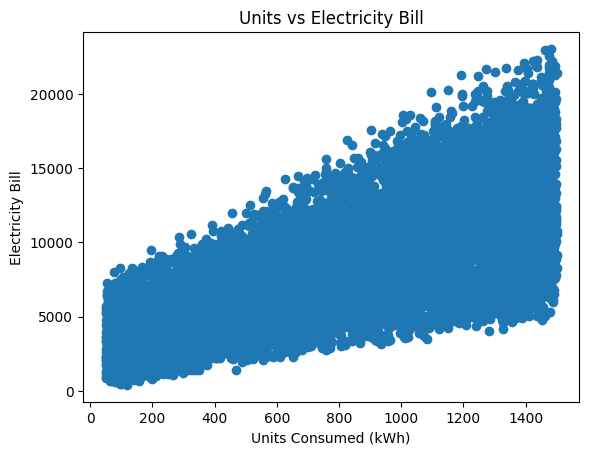

In [ ]:
plt.figure()
plt.scatter(df["Units_Consumed_kWh"], df["Electricity_Bill"])

plt.xlabel("Units Consumed (kWh)")
plt.ylabel("Electricity Bill")
plt.title("Units vs Electricity Bill")

plt.show()

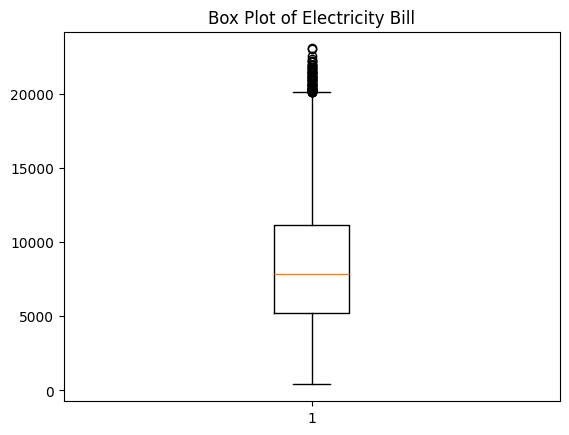

In [ ]:
plt.figure()
plt.boxplot(df["Electricity_Bill"].dropna())

plt.title("Box Plot of Electricity Bill")

plt.show()

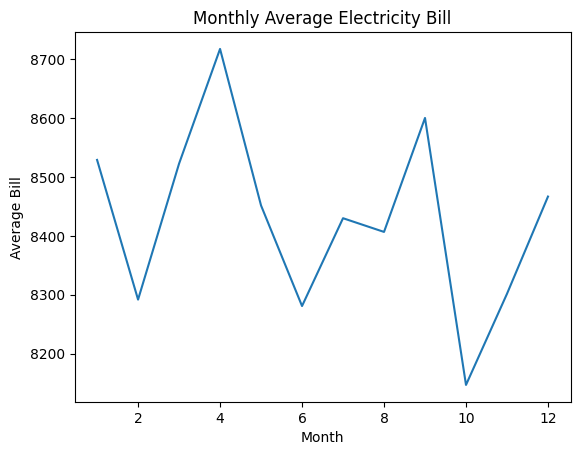

In [ ]:
monthly_avg = df.groupby("Month")["Electricity_Bill"].mean()

plt.figure()
plt.plot(monthly_avg.index, monthly_avg.values)

plt.xlabel("Month")
plt.ylabel("Average Bill")
plt.title("Monthly Average Electricity Bill")

plt.show()

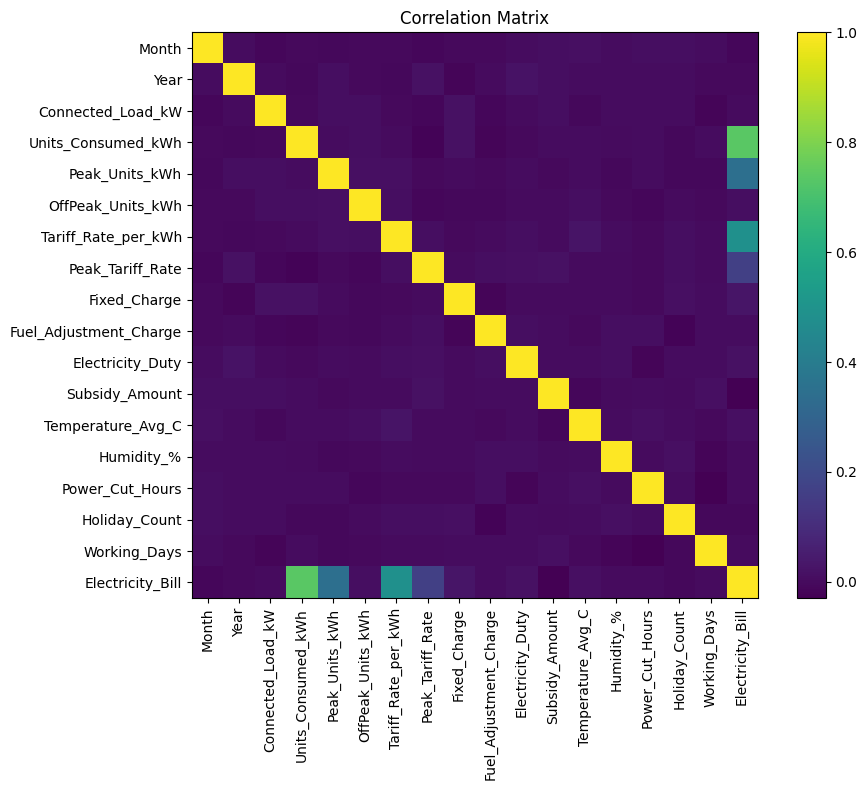

In [ ]:
numeric_data = df.select_dtypes(include=['number'])
corr = numeric_data.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Train test and split

In [ ]:
y = df["Electricity_Bill"]

In [ ]:
y.shape

(11391,)

In [ ]:
y

,Electricity_Bill
0,7315.74
1,13114.50
2,5940.55
3,14833.52
4,14024.71
...,...
13993,9216.60
13994,12559.73
13995,4028.39
13996,1762.16


In [ ]:
X = ["Month	Year",	"Connected_Load_kW",	"Units_Consumed_kWh",	"Peak_Units_kWh",	"OffPeak_Units_kWh",	"Tariff_Rate_per_kWh",	"Peak_Tariff_Rate",	"Fixed_Charge",	"Fuel_Adjustment_Charge",	"Electricity_Duty",	"Subsidy_Amount",	"Temperature_Avg_C",	"Humidity_%",	"Power_Cut_Hours",	"Holiday_Count",	"Working_Days",	"Electricity_Bill"]

In [ ]:
X = df.drop(['Electricity_Bill'], axis=1)

In [ ]:
X

,Month,Year,Connected_Load_kW,Units_Consumed_kWh,Peak_Units_kWh,OffPeak_Units_kWh,Tariff_Rate_per_kWh,Peak_Tariff_Rate,Fixed_Charge,Fuel_Adjustment_Charge,Electricity_Duty,Subsidy_Amount,Temperature_Avg_C,Humidity_%,Power_Cut_Hours,Holiday_Count,Working_Days
0,7,2025,34.68,446.73,407.40,38.25,5.66,12.27,60.05,38.33,65.14,375.07,10.2,64.1,6.3,6,24
1,4,2024,12.00,995.78,376.88,572.19,8.22,12.56,288.09,169.09,28.78,290.38,37.6,62.5,10.7,2,22
2,11,2025,33.28,308.11,406.53,899.05,8.69,7.32,264.57,11.41,40.69,29.40,22.5,40.6,0.6,6,19
3,8,2024,39.15,1233.73,372.46,543.47,7.84,13.82,172.03,10.70,57.94,226.99,43.3,35.8,16.5,2,23
4,5,2023,34.15,1138.12,228.33,73.17,10.73,6.79,270.55,27.98,30.05,66.26,14.4,53.6,13.5,3,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13993,11,2024,42.55,547.26,365.25,772.42,11.52,7.77,164.44,67.79,22.67,180.73,42.3,65.6,15.8,6,26
13994,11,2023,32.82,943.38,350.98,272.51,10.90,5.57,240.88,187.99,1.89,108.83,27.6,62.5,15.6,6,16
13995,4,2022,8.73,774.63,108.66,667.13,4.40,6.06,165.83,149.34,44.81,398.44,20.0,31.4,15.0,3,19
13996,1,2025,28.33,83.50,91.13,537.94,10.91,11.13,121.40,122.49,63.43,470.42,35.6,46.8,5.9,1,23


In [ ]:
X.shape


(11391, 17)

**Model selection**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

**Model Training**

In [ ]:
y_pred = model.predict(X_test)

**Model Evaluation**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
n = X_test.shape[0]
k = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("Adjusted R2:", adj_r2)

MAE: 901.4683804987562
MSE: 1370278.3279440454
RMSE: 1170.588880839061
R2 Score: 0.9230233321843915
Adjusted R2: 0.9224445602459282


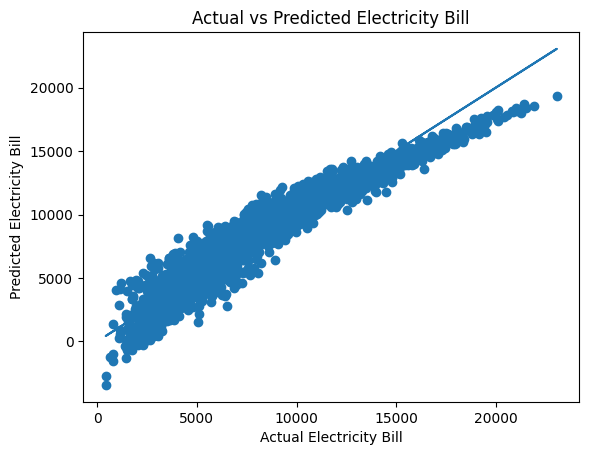

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Electricity Bill")
plt.ylabel("Predicted Electricity Bill")
plt.title("Actual vs Predicted Electricity Bill")

plt.plot(y_test, y_test)

plt.show()

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score



In [ ]:
model = SVR()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("SVM R2 Score:", r2_score(y_test, y_pred))

SVM R2 Score: 0.09823673476877515


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Decision Tree R2:", r2_score(y_test, y_pred))

Decision Tree R2: 0.9660773800084215


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred))

Random Forest R2: 0.9909752494134112


In [ ]:
models = {"Linear Regression": LinearRegression(),"Decision Tree": DecisionTreeRegressor(random_state=42),"Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = r2_score(y_test, y_pred)

print(results)

{'Linear Regression': 0.9230233321843915, 'Decision Tree': 0.9660773800084215, 'Random Forest': 0.9909752494134112}


In [ ]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "R2 Score"])
print(results_df)

               Model  R2 Score
0  Linear Regression  0.923023
1      Decision Tree  0.966077
2      Random Forest  0.990975


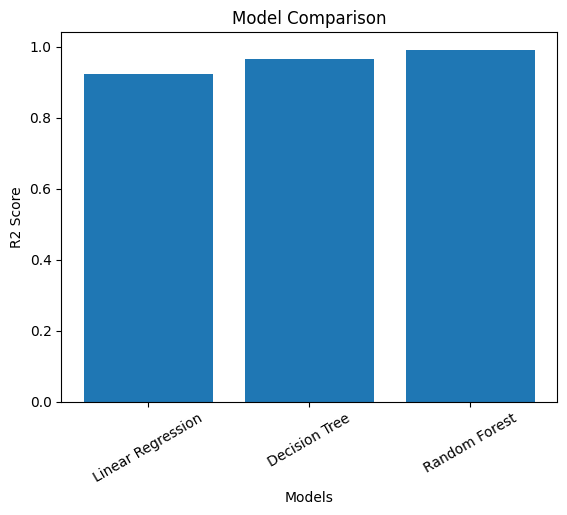

In [ ]:
plt.figure()

plt.bar(results_df["Model"], results_df["R2 Score"])

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison")

plt.xticks(rotation=30)

plt.show()

In [ ]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred})
print(results.head(5))

     Actual   Predicted
0   8755.82   8625.4896
1   5499.37   5559.9175
2   5450.46   5235.6319
3   5526.45   5281.3688
4  14650.77  14430.9460


In [ ]:
results["Error"] = results["Actual"] - results["Predicted"]
print(results.sample(5))

        Actual   Predicted     Error
433   16103.17  16381.3880 -278.2180
1769   6745.82   6834.4072  -88.5872
629    2040.85   2169.6710 -128.8210
23     8774.59   8480.1523  294.4377
467    4933.17   5057.9742 -124.8042
